# WFCRL Synthetic Graph PFN Sandbox
Synthetic wake-graph dataset + baselines + PFN-style in-context graph regressor scaffold.


## 0) Install dependencies
Skip if already installed. This cell pins the NumPy/SciPy/scikit-learn stack used by Colab so `sklearn` does not break after an in-kernel NumPy upgrade. If the cell restarts the runtime, run it once more before continuing. `torch-geometric` install varies by OS/CUDA.


In [1]:
!pip install -q git+https://github.com/ifpen/wfcrl-env.git tabpfn-client torch-geometric python-dotenv "numpy==2.0.2" "scipy==1.16.3" "scikit-learn==1.6.1"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:

import os
from pathlib import Path
from getpass import getpass
from dotenv import dotenv_values, load_dotenv


def clean_secret(value):
    if value is None:
        return None
    value = str(value).strip()
    if (value.startswith('"') and value.endswith('"')) or (value.startswith("'") and value.endswith("'")):
        value = value[1:-1].strip()
    return value or None


def env_candidates():
    cwd = Path.cwd().resolve()
    paths = []

    for folder in [cwd, *cwd.parents]:
        paths.extend([
            folder / ".env",
            folder / "CSCI_5980_notebooks" / ".env",
            folder / "weather-vein" / ".env",
            folder / "weather-vein" / "CSCI_5980_notebooks" / ".env",
        ])

    paths.extend([
        # Local Mac paths used by this project.
        Path("/Users/kevinbabashov/Documents/Spring_2026/CSCI_5980/weather-vein/.env"),
        Path("/Users/kevinbabashov/Documents/Spring_2026/CSCI_5980/weather-vein/CSCI_5980_notebooks/.env"),

        # Colab runtime paths. Colab cannot see your Mac path unless you upload/sync the file.
        Path("/content/.env"),
        Path("/content/CSCI_5980_notebooks/.env"),
        Path("/content/weather-vein/.env"),
        Path("/content/weather-vein/CSCI_5980_notebooks/.env"),
        Path("/content/drive/MyDrive/.env"),
        Path("/content/drive/MyDrive/weather-vein/.env"),
        Path("/content/drive/MyDrive/weather-vein/CSCI_5980_notebooks/.env"),
        Path("/content/drive/MyDrive/CSCI_5980/weather-vein/.env"),
        Path("/content/drive/MyDrive/CSCI_5980/weather-vein/CSCI_5980_notebooks/.env"),
    ])

    unique = []
    seen = set()
    for path in paths:
        path = path.resolve()
        if path not in seen:
            seen.add(path)
            unique.append(path)
    return unique


def load_local_env():
    loaded = []
    token_source = None

    for env_path in env_candidates():
        if not env_path.exists():
            continue

        load_dotenv(env_path, override=True)
        values = dotenv_values(env_path)
        loaded.append(str(env_path))

        for key, value in values.items():
            if not key or value is None:
                continue
            key = key.strip()
            value = clean_secret(value)
            if value is not None:
                os.environ[key] = value
                if key == "TABPFN_TOKEN":
                    token_source = str(env_path)

    return loaded, token_source


def load_colab_secret():
    try:
        from google.colab import userdata
        token = clean_secret(userdata.get("TABPFN_TOKEN"))
        if token:
            return token, "Colab Secrets"
    except Exception:
        pass
    return None, None


def load_tabpfn_token():
    loaded_files, token_source = load_local_env()
    token = clean_secret(os.getenv("TABPFN_TOKEN"))

    if not token:
        token, token_source = load_colab_secret()

    print("Current working directory:", Path.cwd().resolve())
    if loaded_files:
        print("Found .env files:")
        for loaded_file in loaded_files:
            print(" -", loaded_file)
    else:
        print("No .env file found in this runtime.")

    if not token and Path.cwd().resolve() == Path("/content"):
        print("Colab is running on a remote /content machine, so it cannot read your Mac .env file directly.")
        pasted = clean_secret(getpass("Paste TABPFN_TOKEN here once for this runtime, or press Enter to use fallback: "))
        if pasted:
            token = pasted
            token_source = "secure prompt"

    if token:
        os.environ["TABPFN_TOKEN"] = token
        from tabpfn_client import set_access_token
        set_access_token(token)
        print("TabPFN token loaded.")
        print("TABPFN_TOKEN source:", token_source)
        print("TABPFN_TOKEN length:", len(token))
    else:
        print("No TABPFN_TOKEN found.")
        print("In Colab, use the key icon on the left to add a secret named TABPFN_TOKEN, or upload .env to /content.")
        print("TabPFN cells will use TabPFN-Fallback until the token is available.")


load_tabpfn_token()


Current working directory: /content
No .env file found in this runtime.
Colab is running on a remote /content machine, so it cannot read your Mac .env file directly.
TabPFN token loaded.
TABPFN_TOKEN source: secure prompt
TABPFN_TOKEN length: 167


In [3]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"

import numpy as np
import scipy
import sklearn
import torch
import torch_geometric
from sklearn.ensemble import ExtraTreesRegressor


def clean_secret(value):
    if value is None:
        return None
    value = str(value).strip()
    if (value.startswith('"') and value.endswith('"')) or (value.startswith("'") and value.endswith("'")):
        value = value[1:-1].strip()
    return value or None


class SimpleTabPFNRegressor:
    """Hosted TabPFN if TABPFN_TOKEN works; ExtraTrees fallback otherwise."""

    def __init__(self, **kwargs):
        self.kwargs = {k: v for k, v in kwargs.items() if k != "device"}
        self.display_name = "TabPFN"
        self.used_fallback = False
        self.model = None

    def fit(self, X, y):
        try:
            token = clean_secret(os.getenv("TABPFN_TOKEN"))
            if not token:
                raise RuntimeError("TABPFN_TOKEN is not set")

            from tabpfn_client import TabPFNRegressor, set_access_token
            set_access_token(token)

            self.model = TabPFNRegressor(**self.kwargs)
            self.model.fit(X, y)
            self.display_name = "TabPFN"
            self.used_fallback = False
        except Exception as exc:
            print(f"Using TabPFN-Fallback instead of hosted TabPFN ({type(exc).__name__}).")
            self.model = ExtraTreesRegressor(
                n_estimators=256,
                min_samples_leaf=2,
                random_state=0,
                n_jobs=-1,
            )
            self.model.fit(X, y)
            self.display_name = "TabPFN-Fallback"
            self.used_fallback = True
        return self

    def predict(self, X):
        return self.model.predict(X)


print("numpy", np.__version__)
print("scipy", scipy.__version__)
print("sklearn", sklearn.__version__)
print("torch", torch.__version__)
print("torch-geometric", torch_geometric.__version__)


numpy 2.0.2
scipy 1.16.3
sklearn 1.6.1
torch 2.11.0+cu130
torch-geometric 2.7.0


## 1) Synthetic wake graph generator

In [4]:
from __future__ import annotations
import math
import numpy as np
from dataclasses import dataclass
from typing import Tuple, List

@dataclass
class GraphSample:
    x: np.ndarray              # (N, F)
    edge_index: np.ndarray     # (2, E)
    edge_attr: np.ndarray      # (E, A)
    y_total: float
    y_node: np.ndarray         # (N,)

def _angle_wrap_deg(a: float) -> float:
    return (a + 360.0) % 360.0

def _angle_diff_deg(a: float, b: float) -> float:
    d = (a - b + 180.0) % 360.0 - 180.0
    return abs(d)

def _bearing_deg(dx: float, dy: float) -> float:
    # 0 deg = +y (north), 90 deg = +x (east)
    return _angle_wrap_deg(math.degrees(math.atan2(dx, dy)))

def build_wake_graph(
    xy: np.ndarray,
    wind_dir_deg: float,
    dist_thresh: float = 1200.0,
    cone_deg: float = 45.0,
) -> Tuple[np.ndarray, np.ndarray]:
    n = xy.shape[0]
    src, dst, eattr = [], [], []
    downwind = _angle_wrap_deg(wind_dir_deg + 180.0)

    for i in range(n):
        xi, yi = xy[i]
        for j in range(n):
            if i == j:
                continue
            xj, yj = xy[j]
            dx, dy = float(xj - xi), float(yj - yi)
            d = math.hypot(dx, dy)
            if d > dist_thresh:
                continue
            b = _bearing_deg(dx, dy)
            if _angle_diff_deg(b, downwind) <= cone_deg:
                src.append(i)
                dst.append(j)
                eattr.append([d, _angle_diff_deg(b, downwind), d / dist_thresh])

    edge_index = np.asarray([src, dst], dtype=np.int64)
    edge_attr  = np.asarray(eattr, dtype=np.float32) if len(eattr) else np.zeros((0, 3), np.float32)
    return edge_index, edge_attr

def jensen_like_power(
    xy: np.ndarray,
    yaw_deg: np.ndarray,
    wind_speed: float,
    wind_dir_deg: float,
    rotor_diam: float = 126.0,
    ct: float = 0.8,
    k_wake: float = 0.05,
    base_eff: float = 1.0,
) -> np.ndarray:
    n = xy.shape[0]
    ws = wind_speed
    wd = wind_dir_deg
    downwind = _angle_wrap_deg(wd + 180.0)

    th = math.radians(downwind)
    ux, uy = math.sin(th), math.cos(th)

    deficits2 = np.zeros(n, dtype=np.float64)

    yaw_rad = np.deg2rad(yaw_deg)
    yaw_gain = np.cos(yaw_rad) ** 1.88

    for i in range(n):
        xi, yi = xy[i]
        for j in range(n):
            if i == j:
                continue
            xj, yj = xy[j]
            dx, dy = (xj - xi), (yj - yi)

            s = dx * ux + dy * uy
            if s <= 0:
                continue

            cwx = dx - s * ux
            cwy = dy - s * uy
            r = math.hypot(cwx, cwy)

            R = rotor_diam / 2.0 + k_wake * s
            if r > R:
                continue

            yaw_factor = (math.cos(yaw_rad[i]) ** 1.2)
            denom = (1.0 + 2.0 * k_wake * s / rotor_diam) ** 2
            d_ij = (1.0 - math.sqrt(1.0 - ct * yaw_factor)) / denom
            deficits2[j] += d_ij ** 2

    ws_eff = ws * (1.0 - np.sqrt(deficits2))
    ws_eff = np.clip(ws_eff, 0.0, None)

    p = base_eff * (ws_eff ** 3) * yaw_gain
    return p.astype(np.float32)

def sample_synthetic_graph(
    n_turbines: int = 9,
    layout: str = "random",
    area: float = 2000.0,
    wind_speed_range: Tuple[float, float] = (6.0, 12.0),
    wind_dir_range: Tuple[float, float] = (0.0, 360.0),
    yaw_range: Tuple[float, float] = (-25.0, 25.0),
    rng: np.random.Generator | None = None,
    ct: float = 0.8,
    k_wake: float = 0.05,
) -> GraphSample:
    rng = rng or np.random.default_rng()

    if layout == "grid":
        side = int(math.ceil(math.sqrt(n_turbines)))
        xs = np.linspace(0, area, side)
        ys = np.linspace(0, area, side)
        xy = np.array([(x, y) for x in xs for y in ys], dtype=np.float32)[:n_turbines]
    elif layout == "row":
        xy = np.stack([np.linspace(0, area, n_turbines), np.full(n_turbines, area * 0.5)], axis=1).astype(np.float32)
    else:
        xy = rng.uniform(0, area, size=(n_turbines, 2)).astype(np.float32)

    wind_speed = float(rng.uniform(*wind_speed_range))
    wind_dir = float(rng.uniform(*wind_dir_range))
    yaw = rng.uniform(*yaw_range, size=(n_turbines,)).astype(np.float32)

    edge_index, edge_attr = build_wake_graph(xy, wind_dir)

    x = np.column_stack([
        yaw,
        np.full(n_turbines, wind_speed, dtype=np.float32),
        np.full(n_turbines, wind_dir, dtype=np.float32),
        xy[:, 0],
        xy[:, 1],
    ]).astype(np.float32)

    p_node = jensen_like_power(xy, yaw, wind_speed, wind_dir, ct=ct, k_wake=k_wake)
    y_total = float(np.sum(p_node))
    return GraphSample(x=x, edge_index=edge_index, edge_attr=edge_attr, y_total=y_total, y_node=p_node)

def make_dataset(num_samples: int = 5000, n_turbines: int = 9, seed: int = 0) -> List[GraphSample]:
    rng = np.random.default_rng(seed)
    return [sample_synthetic_graph(n_turbines=n_turbines, rng=rng) for _ in range(num_samples)]

s = sample_synthetic_graph(n_turbines=9, layout="random", rng=np.random.default_rng(0))
print("x:", s.x.shape, "edge_index:", s.edge_index.shape, "edge_attr:", s.edge_attr.shape, "y_total:", s.y_total)
print("num edges:", s.edge_index.shape[1])


x: (9, 5) edge_index: (2, 13) edge_attr: (13, 3) y_total: 3145.595703125
num edges: 13


## 2) Graph baseline (GNN) on synthetic data

In [5]:
import torch
import torch.nn as nn

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import GATv2Conv, global_mean_pool
except Exception as e:
    raise RuntimeError(
        "torch_geometric not available. Install PyTorch Geometric first.\n"
        "See: https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html\n"
        f"Original error: {e}"
    )

def to_data(s: GraphSample) -> Data:
    return Data(
        x=torch.tensor(s.x, dtype=torch.float32),
        edge_index=torch.tensor(s.edge_index, dtype=torch.long),
        edge_attr=torch.tensor(s.edge_attr, dtype=torch.float32),
        y=torch.tensor([s.y_total], dtype=torch.float32),
    )

class GNNReg(nn.Module):
    def __init__(self, in_dim=5, hid=64):
        super().__init__()
        self.c1 = GATv2Conv(in_dim, hid, heads=2, concat=False, edge_dim=3)
        self.c2 = GATv2Conv(hid, hid, heads=2, concat=False, edge_dim=3)
        self.lin = nn.Sequential(nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, 1))

    def forward(self, data: Data):
        h = self.c1(data.x, data.edge_index, data.edge_attr).relu()
        h = self.c2(h, data.edge_index, data.edge_attr).relu()
        g = global_mean_pool(h, data.batch)
        return self.lin(g).squeeze(-1)

ds = [to_data(s) for s in make_dataset(num_samples=3000, n_turbines=9, seed=0)]
tr, te = ds[:2600], ds[2600:]

tr_loader = DataLoader(tr, batch_size=64, shuffle=True)
te_loader = DataLoader(te, batch_size=256)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GNNReg().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn = nn.MSELoss()

for ep in range(15):
    model.train()
    for b in tr_loader:
        b = b.to(device)
        pred = model(b)
        loss = loss_fn(pred, b.y.view(-1))
        opt.zero_grad()
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        se = 0.0
        n = 0
        for b in te_loader:
            b = b.to(device)
            pred = model(b)
            se += torch.sum((pred - b.y.view(-1)) ** 2).item()
            n += b.num_graphs
        mse = se / n
    print(f"epoch={ep:02d} test_mse={mse:.4f} device={device}")


epoch=00 test_mse=41754585.6000 device=cpu
epoch=01 test_mse=35443078.4000 device=cpu
epoch=02 test_mse=18466744.9600 device=cpu
epoch=03 test_mse=11307701.7600 device=cpu
epoch=04 test_mse=11169119.6800 device=cpu
epoch=05 test_mse=11148444.4800 device=cpu
epoch=06 test_mse=11124803.2000 device=cpu
epoch=07 test_mse=11104776.3200 device=cpu
epoch=08 test_mse=11086349.1200 device=cpu
epoch=09 test_mse=11068913.2800 device=cpu
epoch=10 test_mse=11036917.7600 device=cpu
epoch=11 test_mse=11015583.6800 device=cpu
epoch=12 test_mse=11002786.8800 device=cpu
epoch=13 test_mse=10975811.8400 device=cpu
epoch=14 test_mse=10966162.2400 device=cpu


## 3) Tabular PFN baseline on flattened node features

In [6]:
rng = np.random.default_rng(0)
samples = [sample_synthetic_graph(n_turbines=9, rng=rng) for _ in range(1200)]
X = np.stack([s.x.reshape(-1) for s in samples], axis=0).astype(np.float32)
y = np.asarray([s.y_total for s in samples], dtype=np.float32)

idx = np.arange(len(samples))
rng.shuffle(idx)
tr_idx, te_idx = idx[:1000], idx[1000:]
X_tr, y_tr = X[tr_idx], y[tr_idx]
X_te, y_te = X[te_idx], y[te_idx]

model = SimpleTabPFNRegressor()
model.fit(X_tr, y_tr)
pred = model.predict(X_te)
mse = float(np.mean((pred - y_te) ** 2))
print("X_tr shape:", X_tr.shape, "X_te shape:", X_te.shape)
print(f"{model.display_name} test MSE:", mse)
if model.used_fallback:
    print("This is not a real TabPFN score. Add TABPFN_TOKEN to .env or Colab Secrets to use hosted TabPFN.")


Processing: 100%|██████████| [00:00<00:00]

X_tr shape: (1000, 45) X_te shape: (200, 45)
TabPFN test MSE: 502474.48218317685


## 4) Synthetic geometric equilibrium labels (best-response)

In [7]:
def best_response_equilibrium(
    xy: np.ndarray,
    wind_speed: float,
    wind_dir: float,
    iters: int = 30,
    yaw_grid: np.ndarray | None = None,
    ct: float = 0.8,
    k_wake: float = 0.05,
) -> np.ndarray:
    n = xy.shape[0]
    yaw = np.zeros(n, dtype=np.float32)
    yaw_grid = yaw_grid if yaw_grid is not None else np.linspace(-25, 25, 21).astype(np.float32)

    for _ in range(iters):
        changed = False
        for i in range(n):
            best_y = yaw[i]
            best_val = -1e18
            for y in yaw_grid:
                yaw_try = yaw.copy()
                yaw_try[i] = y
                p = jensen_like_power(xy, yaw_try, wind_speed, wind_dir, ct=ct, k_wake=k_wake)
                val = float(np.sum(p))
                if val > best_val:
                    best_val = val
                    best_y = y
            if best_y != yaw[i]:
                yaw[i] = best_y
                changed = True
        if not changed:
            break
    return yaw

rng = np.random.default_rng(1)
s = sample_synthetic_graph(n_turbines=9, layout="grid", rng=rng)
xy = s.x[:, 3:5].astype(np.float32)
wind_speed = float(s.x[0, 1])
wind_dir = float(s.x[0, 2])

yaw_eq = best_response_equilibrium(xy, wind_speed, wind_dir)
p_eq = jensen_like_power(xy, yaw_eq, wind_speed, wind_dir)
print("equilibrium yaw:", yaw_eq)
print("total power at eq:", float(np.sum(p_eq)))
print("total power at sample yaw:", s.y_total)


equilibrium yaw: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
total power at eq: 6717.3486328125
total power at sample yaw: 6318.38623046875


## 5) PFN-style in-context graph regressor (minimal B=1 task batching)

In [8]:

import torch
import torch.nn as nn

from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATv2Conv, global_mean_pool

GRAPH_YAW_SCALE = 30.0
GRAPH_WS_SCALE = 15.0

def _normalize_xy_pair(x_coord, y_coord):
    x = np.asarray(x_coord, dtype=np.float32).reshape(-1)
    y = np.asarray(y_coord, dtype=np.float32).reshape(-1)
    x = (x - x.mean()) / (x.std() + 1e-6)
    y = (y - y.mean()) / (y.std() + 1e-6)
    return x, y

def encode_graph_node_features(yaws, wind_speed, wind_dir_deg, x_coord, y_coord):
    yaws = np.asarray(yaws, dtype=np.float32).reshape(-1)
    n = yaws.size

    x_norm, y_norm = _normalize_xy_pair(x_coord, y_coord)

    yaw_norm = yaws / GRAPH_YAW_SCALE
    ws_norm = np.full(n, float(wind_speed) / GRAPH_WS_SCALE, dtype=np.float32)

    wd_rad = np.deg2rad(float(wind_dir_deg))
    wd_sin = np.full(n, np.sin(wd_rad), dtype=np.float32)
    wd_cos = np.full(n, np.cos(wd_rad), dtype=np.float32)

    return np.column_stack([
        yaw_norm,
        ws_norm,
        wd_sin,
        wd_cos,
        x_norm.astype(np.float32),
        y_norm.astype(np.float32),
    ]).astype(np.float32)

class GraphEncoder(nn.Module):
    def __init__(self, in_dim: int, hid: int = 64):
        super().__init__()
        self.g1 = GATv2Conv(in_dim, hid, heads=2, concat=False, edge_dim=3)
        self.g2 = GATv2Conv(hid, hid, heads=2, concat=False, edge_dim=3)
        self.lin = nn.Linear(hid, hid)

    def forward(self, batch_data: Batch):
        edge_index = batch_data.edge_index
        edge_attr  = batch_data.edge_attr

        h = self.g1(batch_data.x, edge_index, edge_attr).relu()
        h = self.g2(h, edge_index, edge_attr).relu()
        g = global_mean_pool(h, batch_data.batch)
        return self.lin(g)

class CrossAttnRegressor(nn.Module):
    def __init__(self, emb: int = 64, heads: int = 4):
        super().__init__()
        self.q_proj = nn.Linear(emb, emb)
        self.k_proj = nn.Linear(emb + 1, emb)
        self.v_proj = nn.Linear(emb + 1, emb)
        self.attn = nn.MultiheadAttention(embed_dim=emb, num_heads=heads, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(emb, emb), nn.ReLU(), nn.Linear(emb, 1))

    def forward(self, q_emb, ctx_emb, ctx_y):
        q = self.q_proj(q_emb).unsqueeze(0)
        k_in = torch.cat([ctx_emb, ctx_y], dim=-1).unsqueeze(0)
        k = self.k_proj(k_in)
        v = self.v_proj(k_in)
        out, _ = self.attn(q, k, v)
        pred = self.mlp(out.squeeze(0)).squeeze(-1)
        return pred

class GraphPFNInContext(nn.Module):
    def __init__(self, node_dim: int = 6, emb: int = 64):
        super().__init__()
        self.enc = GraphEncoder(node_dim, hid=emb)
        self.head = CrossAttnRegressor(emb=emb)

    def forward(self, ctx_batch: Batch, ctx_y: torch.Tensor, q_batch: Batch):
        ctx_emb = self.enc(ctx_batch)
        q_emb = self.enc(q_batch)
        return self.head(q_emb, ctx_emb, ctx_y)

def _graphsample_to_node_x(s: GraphSample) -> np.ndarray:
    x = np.asarray(s.x, dtype=np.float32)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D node feature matrix, got shape {x.shape}")

    if x.shape[1] == 6:
        return x.astype(np.float32)

    if x.shape[1] >= 5:
        yaws = x[:, 0]
        wind_speed = float(x[0, 1])
        wind_dir = float(x[0, 2])
        x_coord = x[:, 3]
        y_coord = x[:, 4]
        return encode_graph_node_features(yaws, wind_speed, wind_dir, x_coord, y_coord)

    raise ValueError(f"Unsupported GraphSample node feature shape {x.shape}; expected 5 or 6 columns.")

def to_pyg(s: GraphSample) -> Data:
    return Data(
        x=torch.tensor(_graphsample_to_node_x(s), dtype=torch.float32),
        edge_index=torch.tensor(s.edge_index, dtype=torch.long),
        edge_attr=torch.tensor(s.edge_attr, dtype=torch.float32),
    )

def sample_task_batch(C: int = 16, Q: int = 16, n_turbines: int = 9, seed: int = 0):
    rng = np.random.default_rng(seed)
    ct = float(rng.uniform(0.6, 0.9))
    k_wake = float(rng.uniform(0.02, 0.08))
    layout = rng.choice(["random", "grid", "row"])

    ctx = [sample_synthetic_graph(n_turbines=n_turbines, layout=layout, rng=rng, ct=ct, k_wake=k_wake) for _ in range(C)]
    qry = [sample_synthetic_graph(n_turbines=n_turbines, layout=layout, rng=rng, ct=ct, k_wake=k_wake) for _ in range(Q)]

    ctx_batch = Batch.from_data_list([to_pyg(s) for s in ctx])
    q_batch   = Batch.from_data_list([to_pyg(s) for s in qry])

    ctx_y_raw = np.asarray([s.y_total for s in ctx], dtype=np.float32)
    q_y_raw   = np.asarray([s.y_total for s in qry], dtype=np.float32)

    y_mean = float(ctx_y_raw.mean())
    y_std = float(ctx_y_raw.std() + 1e-6)

    ctx_y = torch.tensor(((ctx_y_raw - y_mean) / y_std).reshape(-1, 1), dtype=torch.float32)
    q_y   = torch.tensor((q_y_raw - y_mean) / y_std, dtype=torch.float32)
    return ctx_batch, ctx_y, q_batch, q_y

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GraphPFNInContext(node_dim=6, emb=64).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn = nn.MSELoss()

for step in range(100):
    ctx_batch, ctx_y, q_batch, q_y = sample_task_batch(C=16, Q=16, seed=step)
    ctx_batch = ctx_batch.to(device)
    q_batch = q_batch.to(device)
    ctx_y = ctx_y.to(device)
    q_y = q_y.to(device)

    pred = model(ctx_batch, ctx_y, q_batch)
    loss = loss_fn(pred, q_y)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 10 == 0:
        print("step", step, "normalized_loss", float(loss.item()), "device", device)


step 0 normalized_loss 0.7247776389122009 device cpu
step 10 normalized_loss 1.5467660427093506 device cpu
step 20 normalized_loss 0.3611770570278168 device cpu
step 30 normalized_loss 1.1952402591705322 device cpu
step 40 normalized_loss 2.371595859527588 device cpu
step 50 normalized_loss 1.6104559898376465 device cpu
step 60 normalized_loss 1.702734351158142 device cpu
step 70 normalized_loss 0.6493735313415527 device cpu
step 80 normalized_loss 1.067026138305664 device cpu
step 90 normalized_loss 1.5304617881774902 device cpu


## 6) WFCRL integration hook

In [9]:

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import spearmanr
import traceback
import warnings
from pathlib import Path

FIXED_FLORIS_TEST_OPTIONS = {"wind_speed": 8.0, "wind_direction": 270.0}
SCENARIO2_WEIBULL_SHAPE = 8.0
SCENARIO2_WEIBULL_SCALE = 8.0
SCENARIO2_DIRECTION_MEAN = 270.0
SCENARIO2_DIRECTION_STD = 20.0

warnings.filterwarnings("ignore", message=".*get variables from other wrappers is deprecated.*")
warnings.filterwarnings("ignore", message=".*No step size was provided for actuator yaw.*")

try:
    from wfcrl import environments as envs
except Exception as e:
    raise RuntimeError(
        "wfcrl is required for the WFCRL evaluation cells below. "
        "Install/import wfcrl in this environment before running them.\n"
        f"Original error: {e}"
    )

print("WFCRL imported. Number of registered envs:", len(envs.list_envs()) if hasattr(envs, "list_envs") else "unknown")


def _to_plain_obs(reset_or_step_out):
    if isinstance(reset_or_step_out, tuple):
        if len(reset_or_step_out) == 2 and isinstance(reset_or_step_out[1], dict):
            return reset_or_step_out[0]
        if len(reset_or_step_out) >= 1 and isinstance(reset_or_step_out[0], dict):
            return reset_or_step_out[0]
    return reset_or_step_out


def _scalarize_reward(reward):
    arr = np.asarray(reward, dtype=np.float32).reshape(-1)
    if arr.size == 0:
        return 0.0
    return float(arr[0])


def _maybe_array(v):
    try:
        arr = np.asarray(v, dtype=np.float32).reshape(-1)
        if arr.size:
            return arr
    except Exception:
        return None
    return None


def _safe_getattr(obj, name, default=None):
    if obj is None:
        return default

    try:
        gwa = object.__getattribute__(obj, "get_wrapper_attr")
    except Exception:
        gwa = None

    if callable(gwa):
        try:
            val = gwa(name)
            if val is not None:
                return val
        except Exception:
            pass

    try:
        d = object.__getattribute__(obj, "__dict__")
        if isinstance(d, dict) and name in d:
            return d[name]
    except Exception:
        pass

    try:
        return object.__getattribute__(obj, name)
    except Exception:
        return default


def _candidate_objects(env):
    objs = []
    seen = set()

    def add(obj):
        if obj is None:
            return
        oid = id(obj)
        if oid in seen:
            return
        seen.add(oid)
        objs.append(obj)

    add(env)
    add(_safe_getattr(env, "unwrapped", None))

    i = 0
    while i < len(objs):
        obj = objs[i]
        i += 1
        for name in ("farm", "case", "farm_case", "config"):
            add(_safe_getattr(obj, name, None))
    return objs


def get_num_turbines(env, obs=None):
    if obs is not None and isinstance(obs, dict) and "yaw" in obs:
        try:
            return int(np.asarray(obs["yaw"]).reshape(-1).size)
        except Exception:
            pass
    for obj in _candidate_objects(env):
        for name in ("num_turbines", "n_turbines", "n_turbs"):
            val = _safe_getattr(obj, name, None)
            try:
                if val is not None:
                    return int(val)
            except Exception:
                pass
    raise AttributeError("Could not infer number of turbines from env or obs.")


def _valid_layout_pair(x, y, n_expected=None):
    x = _maybe_array(x)
    y = _maybe_array(y)
    if x is None or y is None:
        return None
    if x.size == 0 or y.size == 0 or x.size != y.size:
        return None
    if n_expected is not None and x.size != n_expected:
        return None
    return x.astype(np.float32), y.astype(np.float32)


def get_layout_xy(env, obs=None):
    n_expected = get_num_turbines(env, obs=obs)

    if obs is not None and isinstance(obs, dict):
        for kx, ky in [
            ("layout_x", "layout_y"),
            ("x", "y"),
            ("turbine_x", "turbine_y"),
            ("coordinates_x", "coordinates_y"),
            ("xcoords", "ycoords"),
        ]:
            if kx in obs and ky in obs:
                pair = _valid_layout_pair(obs[kx], obs[ky], n_expected=n_expected)
                if pair is not None:
                    return pair

    attr_pairs = [
        ("layout_x", "layout_y"),
        ("x", "y"),
        ("turbine_x", "turbine_y"),
        ("coordinates_x", "coordinates_y"),
        ("xcoords", "ycoords"),
    ]
    for obj in _candidate_objects(env):
        for xa, ya in attr_pairs:
            pair = _valid_layout_pair(_safe_getattr(obj, xa, None), _safe_getattr(obj, ya, None), n_expected=n_expected)
            if pair is not None:
                return pair

        store = _safe_getattr(obj, "__dict__", None)
        if isinstance(store, dict):
            for xa, ya in attr_pairs:
                pair = _valid_layout_pair(store.get(xa), store.get(ya), n_expected=n_expected)
                if pair is not None:
                    return pair

        for nested_name in ("config", "metadata", "params"):
            nested = _safe_getattr(obj, nested_name, None)
            if isinstance(nested, dict):
                for xa, ya in attr_pairs:
                    pair = _valid_layout_pair(nested.get(xa), nested.get(ya), n_expected=n_expected)
                    if pair is not None:
                        return pair

    x = np.arange(n_expected, dtype=np.float32) * 500.0
    y = np.zeros(n_expected, dtype=np.float32)
    print(f"[get_layout_xy] Falling back to synthetic coordinates for {n_expected} turbines.")
    return x, y


def inspect_env_layout(env_name="Turb3_Row1_Floris", seed=0):
    env = make_env(env_name)
    obs0 = reset_scenario1(env, seed)
    print("env name:", env_name)
    print("obs keys:", list(obs0.keys()) if isinstance(obs0, dict) else type(obs0))
    print("num turbines:", get_num_turbines(env, obs0))
    x, y = get_layout_xy(env, obs0)
    print("layout x shape:", np.asarray(x).shape, "layout y shape:", np.asarray(y).shape)
    print("first coords:", list(zip(np.asarray(x)[:5], np.asarray(y)[:5])))


def extract_freewind(obs):
    if "freewind_measurements" in obs:
        fw = np.asarray(obs["freewind_measurements"], dtype=np.float32).reshape(-1)
        if fw.size >= 2:
            return float(fw[0]), float(fw[1])
    ws = obs.get("wind_speed", 8.0)
    wd = obs.get("wind_direction", 270.0)
    ws = float(np.asarray(ws).reshape(-1)[0])
    wd = float(np.asarray(wd).reshape(-1)[0])
    return ws, wd


def wfcrl_graph_from_yaws(env, yaws, wind_speed, wind_dir, obs=None):
    x_coord, y_coord = get_layout_xy(env, obs=obs)
    xy = np.column_stack([x_coord, y_coord]).astype(np.float32)
    edge_index, edge_attr = build_wake_graph(xy, wind_dir_deg=float(wind_dir))
    node_x = encode_graph_node_features(yaws, wind_speed, wind_dir, x_coord, y_coord)
    n = node_x.shape[0]
    return GraphSample(
        x=node_x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y_total=np.nan,
        y_node=np.zeros(n, dtype=np.float32),
    )


def wfcrl_obs_to_pyg(obs: dict, env):
    ws, wd = extract_freewind(obs)
    return to_pyg(wfcrl_graph_from_yaws(env, obs["yaw"], ws, wd, obs=obs))


def flatten_tabular_features(yaws, env, wind_speed, wind_dir, obs=None):
    x_coord, y_coord = get_layout_xy(env, obs=obs)
    yaws = np.asarray(yaws, dtype=np.float32).reshape(-1)
    wd_rad = np.deg2rad(float(wind_dir))
    feat = np.concatenate([
        (yaws / GRAPH_YAW_SCALE).astype(np.float32),
        np.array([float(wind_speed) / GRAPH_WS_SCALE, np.sin(wd_rad), np.cos(wd_rad)], dtype=np.float32),
        _normalize_xy_pair(x_coord, y_coord)[0].astype(np.float32),
        _normalize_xy_pair(x_coord, y_coord)[1].astype(np.float32),
    ]).astype(np.float32)
    return feat


def _copy_options(options):
    if options is None:
        return None
    return {k: float(v) if np.isscalar(v) else v for k, v in dict(options).items()}


def reset_with_options(env, seed, options=None):
    return _to_plain_obs(env.reset(seed=seed, options=_copy_options(options)))


def reset_scenario1(env, seed):
    return reset_with_options(env, seed=seed, options=FIXED_FLORIS_TEST_OPTIONS)


def _freewind_bounds(env=None):
    low = np.array([3.0, 0.0], dtype=np.float32)
    high = np.array([28.0, 360.0], dtype=np.float32)
    space = _safe_getattr(env, "observation_space", None)
    try:
        fw_space = space["freewind_measurements"]
        low = np.asarray(fw_space.low, dtype=np.float32).reshape(-1)[:2]
        high = np.asarray(fw_space.high, dtype=np.float32).reshape(-1)[:2]
    except Exception:
        pass
    return low, high


def sample_scenario2_options(rng, env=None):
    """WFCRL Scenario 2 train-time context: Weibull wind speed, Normal wind direction."""
    low, high = _freewind_bounds(env)
    wind_speed = SCENARIO2_WEIBULL_SCALE * rng.weibull(SCENARIO2_WEIBULL_SHAPE)
    wind_direction = rng.normal(SCENARIO2_DIRECTION_MEAN, SCENARIO2_DIRECTION_STD) % 360.0
    return {
        "wind_speed": float(np.clip(wind_speed, low[0], high[0])),
        "wind_direction": float(np.clip(wind_direction, low[1], high[1])),
    }


def _sample_context_options(options_sampler, rng, env):
    if options_sampler is None:
        return None
    try:
        return _copy_options(options_sampler(rng, env))
    except TypeError:
        return _copy_options(options_sampler(rng))


def ramp_and_eval(env, target_yaws, seed, options=None):
    eval_options = FIXED_FLORIS_TEST_OPTIONS if options is None else options
    obs = reset_with_options(env, seed=seed, options=eval_options)
    total_reward = 0.0
    total_power = 0.0
    done = False
    while not done:
        curr = np.asarray(obs["yaw"], dtype=np.float32)
        delta = np.clip(np.asarray(target_yaws, dtype=np.float32) - curr, -5.0, 5.0)
        obs, reward, term, trunc, info = env.step({"yaw": delta})
        obs = _to_plain_obs(obs)
        total_reward += _scalarize_reward(reward)
        if isinstance(info, dict) and "power" in info:
            total_power += float(np.sum(info["power"]))
        done = bool(term or trunc)
    return total_reward, total_power


def collect_context_data(
    env,
    seed,
    n_initial=32,
    yaw_low=-40.0,
    yaw_high=40.0,
    context_options=None,
    options_sampler=None,
    reference_options=None,
):
    reference_options = FIXED_FLORIS_TEST_OPTIONS if reference_options is None else reference_options
    default_context_options = (
        FIXED_FLORIS_TEST_OPTIONS
        if context_options is None and options_sampler is None
        else context_options
    )

    obs0 = reset_with_options(env, seed=seed, options=reference_options)
    ws, wd = extract_freewind(obs0)
    n_turbines = get_num_turbines(env, obs0)

    X_tab, y_reward, y_power = [], [], []
    graph_list, yaw_list, context_options_used = [], [], []
    context_ws, context_wd = [], []

    rng = np.random.default_rng(seed)
    for sample_idx in range(n_initial):
        yaws = rng.uniform(yaw_low, yaw_high, size=n_turbines).astype(np.float32)
        sampled_options = _sample_context_options(options_sampler, rng, env)
        sample_options = sampled_options if sampled_options is not None else default_context_options
        sample_seed = seed + sample_idx + 1
        obs_i = reset_with_options(env, seed=sample_seed, options=sample_options)
        ws_i, wd_i = extract_freewind(obs_i)
        reward, power = ramp_and_eval(env, yaws, seed=sample_seed, options=sample_options)

        X_tab.append(flatten_tabular_features(yaws, env, ws_i, wd_i, obs=obs_i))
        graph_list.append(wfcrl_graph_from_yaws(env, yaws, ws_i, wd_i, obs=obs_i))
        y_reward.append(reward)
        y_power.append(power)
        yaw_list.append(yaws)
        context_options_used.append(_copy_options(sample_options))
        context_ws.append(ws_i)
        context_wd.append(wd_i)

    return {
        "obs0": obs0,
        "ws": ws,
        "wd": wd,
        "X_tab": np.asarray(X_tab, dtype=np.float32),
        "y_reward": np.asarray(y_reward, dtype=np.float32),
        "y_power": np.asarray(y_power, dtype=np.float32),
        "graphs": graph_list,
        "yaws": yaw_list,
        "context_options": context_options_used,
        "context_ws": np.asarray(context_ws, dtype=np.float32),
        "context_wd": np.asarray(context_wd, dtype=np.float32),
    }


def fit_gp_model(X, y):
    kernel = (
        C(1.0, (1e-3, 1e3))
        * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e3))
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    )
    gp = Pipeline([
        ("scaler", StandardScaler()),
        ("gp", GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=0)),
    ])
    gp.fit(X, y)
    return gp


def fit_tabpfn_model(X, y, device="cpu"):
    return SimpleTabPFNRegressor(device=device).fit(X, y)


def score_graphpfn_candidates(graph_pfn_model, ctx_graphs, ctx_y, candidate_graphs, device="cpu", batch_size=128):
    graph_pfn_model.eval()

    ctx_y_np = np.asarray(ctx_y, dtype=np.float32).reshape(-1)
    y_mean = float(ctx_y_np.mean())
    y_std = float(ctx_y_np.std() + 1e-6)
    ctx_y_norm = ((ctx_y_np - y_mean) / y_std).reshape(-1, 1)

    ctx_batch = Batch.from_data_list([to_pyg(g) for g in ctx_graphs]).to(device)
    ctx_y_t = torch.tensor(ctx_y_norm, dtype=torch.float32, device=device)

    preds = []
    with torch.no_grad():
        for start in range(0, len(candidate_graphs), batch_size):
            q_graphs = candidate_graphs[start:start + batch_size]
            q_batch = Batch.from_data_list([to_pyg(g) for g in q_graphs]).to(device)
            pred = graph_pfn_model(ctx_batch, ctx_y_t, q_batch)
            preds.append(pred.detach().cpu().numpy())
    return np.concatenate(preds, axis=0).reshape(-1)


def random_search_with_surrogate(env, obs0, surrogate_predict, n_candidates=1024, yaw_low=-40.0, yaw_high=40.0, seed=0):
    rng = np.random.default_rng(seed)
    n_turbines = get_num_turbines(env, obs0)
    cand_yaws = rng.uniform(yaw_low, yaw_high, size=(n_candidates, n_turbines)).astype(np.float32)
    scores = np.asarray(surrogate_predict(cand_yaws)).reshape(-1)
    best_idx = int(np.argmax(scores))
    return cand_yaws[best_idx], float(scores[best_idx])


def do_nothing_yaws(env, obs=None):
    return np.zeros(get_num_turbines(env, obs), dtype=np.float32)


def random_yaws(env, seed=0, yaw_low=-40.0, yaw_high=40.0, obs=None):
    rng = np.random.default_rng(seed)
    return rng.uniform(yaw_low, yaw_high, size=get_num_turbines(env, obs)).astype(np.float32)


def sample_yaw_candidates(env, n_candidates=1024, seed=0, yaw_low=-40.0, yaw_high=40.0, obs=None):
    rng = np.random.default_rng(seed)
    n_turbines = get_num_turbines(env, obs)
    return rng.uniform(yaw_low, yaw_high, size=(n_candidates, n_turbines)).astype(np.float32)


def graphpfn_rank_diagnostic(
    env_name,
    seed,
    graph_pfn_model,
    n_candidates=256,
    scenario_name="Scenario 1",
    context_options=None,
    options_sampler=None,
    eval_options=None,
):
    env = make_env(env_name)
    eval_options = FIXED_FLORIS_TEST_OPTIONS if eval_options is None else eval_options
    context = collect_context_data(
        env,
        seed=seed,
        n_initial=N_INITIAL,
        context_options=context_options,
        options_sampler=options_sampler,
        reference_options=eval_options,
    )
    obs0 = context["obs0"]
    ws, wd = context["ws"], context["wd"]
    X_tab = context["X_tab"]
    y = context["y_reward"]
    ctx_graphs = context["graphs"]

    gp_model = fit_gp_model(X_tab, y)
    tabpfn_model = fit_tabpfn_model(X_tab, y, device=TABPFN_DEVICE)

    rng = np.random.default_rng(seed + 12345)
    n_turbines = get_num_turbines(env, obs0)
    cand_yaws = rng.uniform(-40.0, 40.0, size=(n_candidates, n_turbines)).astype(np.float32)

    true_rewards = np.array(
        [ramp_and_eval(env, yw, seed=seed, options=eval_options)[0] for yw in cand_yaws],
        dtype=np.float32,
    )

    X_cand = np.stack([flatten_tabular_features(yw, env, ws, wd, obs=obs0) for yw in cand_yaws], axis=0)
    gp_scores = gp_model.predict(X_cand)
    tab_scores = tabpfn_model.predict(X_cand)

    q_graphs = [wfcrl_graph_from_yaws(env, yw, ws, wd, obs=obs0) for yw in cand_yaws]
    graph_scores = score_graphpfn_candidates(
        graph_pfn_model=graph_pfn_model,
        ctx_graphs=ctx_graphs,
        ctx_y=y,
        candidate_graphs=q_graphs,
        device=GRAPH_PFN_DEVICE,
    )

    tabpfn_label = getattr(tabpfn_model, "display_name", "TabPFN")
    out = pd.DataFrame({
        "scenario": [scenario_name, scenario_name, scenario_name],
        "method": ["GP", tabpfn_label, "GraphPFN"],
        "spearman_rank_corr": [
            spearmanr(gp_scores, true_rewards).correlation,
            spearmanr(tab_scores, true_rewards).correlation,
            spearmanr(graph_scores, true_rewards).correlation,
        ],
    })
    return out


WFCRL imported. Number of registered envs: 88


## WFCRL Scenario 1 comparison across many FLORIS environments
These cells compare Do-Nothing, Random, GP, TabPFN, and GraphPFN under fixed wind speed 8 and wind direction 270.
By default this notebook now runs across all registered FLORIS layouts, not just the 2 slide-18 layouts.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

SCENARIO1_OPTIONS = FIXED_FLORIS_TEST_OPTIONS.copy()
GRAPH_PFN_DEVICE = device
TABPFN_DEVICE = "cpu"
N_INITIAL = 32
N_CANDIDATES = 1024
SEEDS = [0, 1, 2]

# Exact Scenario 1 FLORIS environments used in slide 18
SLIDE18_LAYOUTS = ['Ablaincourt_Floris', 'HornsRev1_Floris', 'HornsRev2_Floris', 'Ormonde_Floris', 'Turb10_Row1_Floris', 'Turb11_Row1_Floris', 'Turb12_Row1_Floris', 'Turb16_Row5_Floris', 'Turb2_Row1_Floris', 'Turb32_Row5_Floris', 'Turb3_Row1_Floris', 'Turb4_Row1_Floris', 'Turb5_Row1_Floris', 'Turb6_Row1_Floris', 'Turb6_Row2_Floris', 'Turb7_Row1_Floris', 'Turb8_Row1_Floris', 'Turb9_Row1_Floris', 'Turb_TCRWP_Floris', 'WMR_Floris']
FALLBACK_LAYOUTS = ["Turb3_Row1_Floris", "Ablaincourt_Floris"]


def make_env(env_name):
    return envs.make(
        env_name,
        max_num_steps=150,
        controls={"yaw": (-5, 5)},
        continuous_control=True,
        log=True,
    )


def list_registered_floris_layouts():
    names = []
    if hasattr(envs, "data_cases") and hasattr(envs.data_cases, "named_cases_dictionary"):
        names = list(envs.data_cases.named_cases_dictionary.keys())
    floris_names = [n for n in names if isinstance(n, str) and n.endswith("_Floris")]
    return sorted(floris_names)


def validate_layouts(layouts):
    valid_layouts = []
    invalid_layouts = []
    for name in layouts:
        try:
            _ = make_env(name)
            valid_layouts.append(name)
            print(f"OK: {name}")
        except Exception as e:
            invalid_layouts.append((name, str(e)))
            print(f"BAD: {name} -> {e}")
    return valid_layouts, invalid_layouts


ALL_FLORIS_LAYOUTS = list_registered_floris_layouts()
print("Registered FLORIS layouts:", ALL_FLORIS_LAYOUTS)

print("\nValidating exact slide 18 layouts...")
LAYOUTS, BAD_LAYOUTS = validate_layouts(SLIDE18_LAYOUTS)

if BAD_LAYOUTS:
    print("\nSlide 18 layouts missing or invalid in this local WFCRL install:")
    for name, err in BAD_LAYOUTS:
        print(" ", name, "->", err)

if not LAYOUTS:
    print("\nNo slide 18 layouts validated. Falling back to known layouts.")
    LAYOUTS, BAD_LAYOUTS = validate_layouts(FALLBACK_LAYOUTS)

print("\nValidated slide-18 layouts:", LAYOUTS)
if len(LAYOUTS) < len(SLIDE18_LAYOUTS):
    print("Using the subset that exists locally.")


Registered FLORIS layouts: []

Validating exact slide 18 layouts...
OK: Ablaincourt_Floris
OK: HornsRev1_Floris
OK: HornsRev2_Floris
OK: Ormonde_Floris
OK: Turb10_Row1_Floris
OK: Turb11_Row1_Floris
OK: Turb12_Row1_Floris
OK: Turb16_Row5_Floris
OK: Turb2_Row1_Floris
OK: Turb32_Row5_Floris
OK: Turb3_Row1_Floris
OK: Turb4_Row1_Floris
OK: Turb5_Row1_Floris
OK: Turb6_Row1_Floris
OK: Turb6_Row2_Floris
OK: Turb7_Row1_Floris
OK: Turb8_Row1_Floris
OK: Turb9_Row1_Floris
OK: Turb_TCRWP_Floris
OK: WMR_Floris

Validated slide-18 layouts: ['Ablaincourt_Floris', 'HornsRev1_Floris', 'HornsRev2_Floris', 'Ormonde_Floris', 'Turb10_Row1_Floris', 'Turb11_Row1_Floris', 'Turb12_Row1_Floris', 'Turb16_Row5_Floris', 'Turb2_Row1_Floris', 'Turb32_Row5_Floris', 'Turb3_Row1_Floris', 'Turb4_Row1_Floris', 'Turb5_Row1_Floris', 'Turb6_Row1_Floris', 'Turb6_Row2_Floris', 'Turb7_Row1_Floris', 'Turb8_Row1_Floris', 'Turb9_Row1_Floris', 'Turb_TCRWP_Floris', 'WMR_Floris']


In [11]:
for name in LAYOUTS[:min(3, len(LAYOUTS))]:
    inspect_env_layout(name, seed=0)


env name: Ablaincourt_Floris
obs keys: ['yaw', 'freewind_measurements', 'wind_speed', 'wind_direction']
num turbines: 7
layout x shape: (7,) layout y shape: (7,)
first coords: [(np.float32(484.8), np.float32(274.0)), (np.float32(797.1), np.float32(251.0)), (np.float32(1038.8), np.float32(66.9)), (np.float32(1377.6), np.float32(-22.7)), (np.float32(1716.9), np.float32(-112.5))]
env name: HornsRev1_Floris
obs keys: ['yaw', 'freewind_measurements', 'wind_speed', 'wind_direction']
num turbines: 80
layout x shape: (80,) layout y shape: (80,)
first coords: [(np.float32(0.0), np.float32(1945.5282)), (np.float32(68.28454), np.float32(1387.2451)), (np.float32(136.11176), np.float32(832.701)), (np.float32(203.97049), np.float32(277.89923)), (np.float32(272.04214), np.float32(-278.6432))]
env name: HornsRev2_Floris
obs keys: ['yaw', 'freewind_measurements', 'wind_speed', 'wind_direction']
num turbines: 91
layout x shape: (91,) layout y shape: (91,)
first coords: [(np.float32(3586.6902), np.float3

In [12]:
def run_one_layout_seed(
    env_name,
    seed,
    graph_pfn_model,
    scenario_name="Scenario 1",
    context_options=None,
    options_sampler=None,
    eval_options=None,
):
    env = make_env(env_name)
    eval_options = FIXED_FLORIS_TEST_OPTIONS if eval_options is None else eval_options
    context = collect_context_data(
        env,
        seed=seed,
        n_initial=N_INITIAL,
        context_options=context_options,
        options_sampler=options_sampler,
        reference_options=eval_options,
    )
    obs0 = context["obs0"]
    ws, wd = context["ws"], context["wd"]
    X_tab = context["X_tab"]
    y = context["y_reward"]
    ctx_graphs = context["graphs"]

    print(
        f"[run_one_layout_seed] {scenario_name} {env_name} seed={seed} "
        f"X_tab={X_tab.shape} y={y.shape} graphs={len(ctx_graphs)} "
        f"test_ws={ws:.3f} test_wd={wd:.3f}"
    )
    if "context_ws" in context and len(context["context_ws"]):
        print(
            "  train context ws range=",
            (float(np.min(context["context_ws"])), float(np.max(context["context_ws"]))),
            "wd range=",
            (float(np.min(context["context_wd"])), float(np.max(context["context_wd"]))),
        )

    gp_model = fit_gp_model(X_tab, y)
    tabpfn_model = fit_tabpfn_model(X_tab, y, device=TABPFN_DEVICE)

    def gp_predict(cand_yaws):
        X = np.stack([flatten_tabular_features(yw, env, ws, wd, obs=obs0) for yw in cand_yaws], axis=0)
        return gp_model.predict(X)

    def tabpfn_predict(cand_yaws):
        X = np.stack([flatten_tabular_features(yw, env, ws, wd, obs=obs0) for yw in cand_yaws], axis=0)
        return tabpfn_model.predict(X)

    def graphpfn_predict(cand_yaws):
        q_graphs = [wfcrl_graph_from_yaws(env, yw, ws, wd, obs=obs0) for yw in cand_yaws]
        return score_graphpfn_candidates(
            graph_pfn_model=graph_pfn_model,
            ctx_graphs=ctx_graphs,
            ctx_y=y,
            candidate_graphs=q_graphs,
            device=GRAPH_PFN_DEVICE,
            batch_size=128,
        )

    yaw_do_nothing = do_nothing_yaws(env, obs0)
    yaw_random = random_yaws(env, seed=seed, obs=obs0)
    yaw_gp, pred_gp = random_search_with_surrogate(env, obs0, gp_predict, n_candidates=N_CANDIDATES, seed=seed)
    yaw_tabpfn, pred_tabpfn = random_search_with_surrogate(env, obs0, tabpfn_predict, n_candidates=N_CANDIDATES, seed=seed + 1000)
    yaw_graphpfn, pred_graphpfn = random_search_with_surrogate(env, obs0, graphpfn_predict, n_candidates=N_CANDIDATES, seed=seed + 2000)
    tabpfn_label = getattr(tabpfn_model, "display_name", "TabPFN")

    methods = {
        "Do-Nothing": yaw_do_nothing,
        "Random": yaw_random,
        "GP": yaw_gp,
        tabpfn_label: yaw_tabpfn,
        "GraphPFN": yaw_graphpfn,
    }

    predicted_scores = {
        "Do-Nothing": np.nan,
        "Random": np.nan,
        "GP": pred_gp,
        tabpfn_label: pred_tabpfn,
        "GraphPFN": pred_graphpfn,
    }

    rows = []
    for method, yaws in methods.items():
        reward, power = ramp_and_eval(env, yaws, seed=seed, options=eval_options)
        rows.append({
            "scenario": scenario_name,
            "layout": env_name,
            "seed": seed,
            "method": method,
            "reward": float(reward),
            "power": float(power),
            "predicted_reward": float(predicted_scores[method]) if np.isfinite(predicted_scores[method]) else np.nan,
            "test_wind_speed": float(ws),
            "test_wind_direction": float(wd),
            "train_wind_speed_min": float(np.min(context["context_ws"])),
            "train_wind_speed_max": float(np.max(context["context_ws"])),
            "train_wind_direction_min": float(np.min(context["context_wd"])),
            "train_wind_direction_max": float(np.max(context["context_wd"])),
            "n_turbines": int(get_num_turbines(env, obs0)),
        })
    return pd.DataFrame(rows)


In [13]:
def preflight_one_layout(
    env_name,
    seed=0,
    graph_pfn_model=None,
    n_candidates_small=64,
    scenario_name="Scenario 1",
    context_options=None,
    options_sampler=None,
    eval_options=None,
):
    try:
        env = make_env(env_name)
        eval_options = FIXED_FLORIS_TEST_OPTIONS if eval_options is None else eval_options
        context = collect_context_data(
            env,
            seed=seed,
            n_initial=min(N_INITIAL, 16),
            context_options=context_options,
            options_sampler=options_sampler,
            reference_options=eval_options,
        )
        obs0 = context["obs0"]
        ws, wd = context["ws"], context["wd"]
        X_tab = context["X_tab"]
        y = context["y_reward"]
        ctx_graphs = context["graphs"]

        gp_model = fit_gp_model(X_tab, y)
        tabpfn_model = fit_tabpfn_model(X_tab, y, device=TABPFN_DEVICE)

        cand_yaws = sample_yaw_candidates(env, n_candidates=n_candidates_small, seed=seed + 999, obs=obs0)
        q_graphs = [wfcrl_graph_from_yaws(env, yw, ws, wd, obs=obs0) for yw in cand_yaws[:8]]
        _ = score_graphpfn_candidates(
            graph_pfn_model=graph_pfn_model,
            ctx_graphs=ctx_graphs,
            ctx_y=y,
            candidate_graphs=q_graphs,
            device=GRAPH_PFN_DEVICE,
            batch_size=32,
        )
        _ = gp_model.predict(np.stack([flatten_tabular_features(yw, env, ws, wd, obs=obs0) for yw in cand_yaws[:8]], axis=0))
        _ = tabpfn_model.predict(np.stack([flatten_tabular_features(yw, env, ws, wd, obs=obs0) for yw in cand_yaws[:8]], axis=0))
        return {"scenario": scenario_name, "layout": env_name, "ok": True, "error": ""}
    except Exception as e:
        return {
            "scenario": scenario_name,
            "layout": env_name,
            "ok": False,
            "error": f"{type(e).__name__}: {e}",
            "traceback": traceback.format_exc(),
        }


preflight_rows = [preflight_one_layout(name, seed=0, graph_pfn_model=model) for name in LAYOUTS]
preflight_df = pd.DataFrame(preflight_rows)
display(preflight_df[[c for c in ["scenario", "layout", "ok", "error"] if c in preflight_df.columns]])

WORKING_LAYOUTS = preflight_df.loc[preflight_df["ok"] == True, "layout"].tolist() if len(preflight_df) else []
if not WORKING_LAYOUTS and LAYOUTS != FALLBACK_LAYOUTS:
    print("No registered layouts passed preflight. Retrying fallback layouts.")
    fallback_valid, fallback_bad = validate_layouts(FALLBACK_LAYOUTS)
    preflight_rows = [preflight_one_layout(name, seed=0, graph_pfn_model=model) for name in fallback_valid]
    preflight_df = pd.DataFrame(preflight_rows)
    display(preflight_df[[c for c in ["scenario", "layout", "ok", "error"] if c in preflight_df.columns]])
    WORKING_LAYOUTS = preflight_df.loc[preflight_df["ok"] == True, "layout"].tolist() if len(preflight_df) else []

print("Working layouts for full evaluation:", WORKING_LAYOUTS)


Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
Processing: 100%|██████████| [00:00<00:00]
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
Processing: 100%|██████████| [00:00<00:00]
Processin

,scenario,layout,ok,error
0,Scenario 1,Ablaincourt_Floris,True,
1,Scenario 1,HornsRev1_Floris,True,
2,Scenario 1,HornsRev2_Floris,True,
3,Scenario 1,Ormonde_Floris,True,
4,Scenario 1,Turb10_Row1_Floris,True,
5,Scenario 1,Turb11_Row1_Floris,True,
6,Scenario 1,Turb12_Row1_Floris,True,
7,Scenario 1,Turb16_Row5_Floris,True,
8,Scenario 1,Turb2_Row1_Floris,True,
9,Scenario 1,Turb32_Row5_Floris,True,


Working layouts for full evaluation: ['Ablaincourt_Floris', 'HornsRev1_Floris', 'HornsRev2_Floris', 'Ormonde_Floris', 'Turb10_Row1_Floris', 'Turb11_Row1_Floris', 'Turb12_Row1_Floris', 'Turb16_Row5_Floris', 'Turb2_Row1_Floris', 'Turb32_Row5_Floris', 'Turb3_Row1_Floris', 'Turb4_Row1_Floris', 'Turb5_Row1_Floris', 'Turb6_Row1_Floris', 'Turb6_Row2_Floris', 'Turb7_Row1_Floris', 'Turb8_Row1_Floris', 'Turb9_Row1_Floris', 'Turb_TCRWP_Floris', 'WMR_Floris']


In [14]:
all_runs = []
error_rows = []
RUN_LAYOUTS = WORKING_LAYOUTS if len(WORKING_LAYOUTS) else LAYOUTS
print("Evaluating layouts:", RUN_LAYOUTS)

for env_name in RUN_LAYOUTS:
    print(f"\nRunning {env_name}")
    for seed in SEEDS:
        try:
            df_run = run_one_layout_seed(env_name, seed, model)
            all_runs.append(df_run)
            print(df_run[["layout", "seed", "method", "reward"]])
        except Exception as e:
            error_rows.append({
                "layout": env_name,
                "seed": seed,
                "error_type": type(e).__name__,
                "error": str(e),
                "traceback": traceback.format_exc(),
            })
            print(f"FAILED {env_name} seed={seed}: {type(e).__name__}: {e}")

errors_df = pd.DataFrame(error_rows)
if len(errors_df):
    display(errors_df[["layout", "seed", "error_type", "error"]])

if not all_runs:
    raise RuntimeError(
        "No results were collected because every layout failed preflight or evaluation. "
        "Check preflight_df and errors_df above for the first real exception."
    )

results_df = pd.concat(all_runs, ignore_index=True)
display(results_df.head())



Evaluating layouts: ['Ablaincourt_Floris', 'HornsRev1_Floris', 'HornsRev2_Floris', 'Ormonde_Floris', 'Turb10_Row1_Floris', 'Turb11_Row1_Floris', 'Turb12_Row1_Floris', 'Turb16_Row5_Floris', 'Turb2_Row1_Floris', 'Turb32_Row5_Floris', 'Turb3_Row1_Floris', 'Turb4_Row1_Floris', 'Turb5_Row1_Floris', 'Turb6_Row1_Floris', 'Turb6_Row2_Floris', 'Turb7_Row1_Floris', 'Turb8_Row1_Floris', 'Turb9_Row1_Floris', 'Turb_TCRWP_Floris', 'WMR_Floris']

Running Ablaincourt_Floris
[run_one_layout_seed] Scenario 1 Ablaincourt_Floris seed=0 X_tab=(32, 24) y=(32,) graphs=32 test_ws=8.000 test_wd=270.000
  train context ws range= (8.0, 8.0) wd range= (270.0, 270.0)


Processing: 100%|██████████| [00:00<00:00]


               layout  seed      method      reward
0  Ablaincourt_Floris     0  Do-Nothing  351.166729
1  Ablaincourt_Floris     0      Random  348.796185
2  Ablaincourt_Floris     0          GP  363.991040
3  Ablaincourt_Floris     0      TabPFN  363.986404
4  Ablaincourt_Floris     0    GraphPFN  350.256168
[run_one_layout_seed] Scenario 1 Ablaincourt_Floris seed=1 X_tab=(32, 24) y=(32,) graphs=32 test_ws=8.000 test_wd=270.000
  train context ws range= (8.0, 8.0) wd range= (270.0, 270.0)


Processing: 100%|██████████| [00:00<00:00]


               layout  seed      method      reward
0  Ablaincourt_Floris     1  Do-Nothing  351.166729
1  Ablaincourt_Floris     1      Random  355.206798
2  Ablaincourt_Floris     1          GP  365.240018
3  Ablaincourt_Floris     1      TabPFN  360.090692
4  Ablaincourt_Floris     1    GraphPFN  346.681357
[run_one_layout_seed] Scenario 1 Ablaincourt_Floris seed=2 X_tab=(32, 24) y=(32,) graphs=32 test_ws=8.000 test_wd=270.000
  train context ws range= (8.0, 8.0) wd range= (270.0, 270.0)


...

Processing: 100%|██████████| [00:01<00:00]


       layout  seed      method      reward
0  WMR_Floris     1  Do-Nothing  475.011106
1  WMR_Floris     1      Random  471.035333
2  WMR_Floris     1          GP  473.378953
3  WMR_Floris     1      TabPFN  474.099766
4  WMR_Floris     1    GraphPFN  469.416504
[run_one_layout_seed] Scenario 1 WMR_Floris seed=2 X_tab=(32, 108) y=(32,) graphs=32 test_ws=8.000 test_wd=270.000
  train context ws range= (8.0, 8.0) wd range= (270.0, 270.0)


Processing: 100%|██████████| [00:00<00:00]


       layout  seed      method      reward
0  WMR_Floris     2  Do-Nothing  475.011106
1  WMR_Floris     2      Random  471.471093
2  WMR_Floris     2          GP  473.727297
3  WMR_Floris     2      TabPFN  472.117403
4  WMR_Floris     2    GraphPFN  469.621254


,scenario,layout,seed,method,reward,power,predicted_reward,test_wind_speed,test_wind_direction,train_wind_speed_min,train_wind_speed_max,train_wind_direction_min,train_wind_direction_max,n_turbines
0,Scenario 1,Ablaincourt_Floris,0,Do-Nothing,351.166729,1271.612952,NaN,8.0,270.0,8.0,8.0,270.0,270.0,7
1,Scenario 1,Ablaincourt_Floris,0,Random,348.796185,1262.806496,NaN,8.0,270.0,8.0,8.0,270.0,270.0,7
2,Scenario 1,Ablaincourt_Floris,0,GP,363.991040,1317.095802,366.182131,8.0,270.0,8.0,8.0,270.0,270.0,7
3,Scenario 1,Ablaincourt_Floris,0,TabPFN,363.986404,1317.095802,362.196655,8.0,270.0,8.0,8.0,270.0,270.0,7
4,Scenario 1,Ablaincourt_Floris,0,GraphPFN,350.256168,1268.178380,-0.015486,8.0,270.0,8.0,8.0,270.0,270.0,7


In [15]:
graphpfn_rank_diagnostic('Turb3_Row1_Floris', seed=0, graph_pfn_model=model, n_candidates=128)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
Processing: 100%|██████████| [00:00<00:00]


,scenario,method,spearman_rank_corr
0,Scenario 1,GP,0.684937
1,Scenario 1,TabPFN,0.799485
2,Scenario 1,GraphPFN,0.244239


In [16]:
methods_order = ["Do-Nothing", "Random", "GP", "TabPFN", "TabPFN-Fallback", "GraphPFN"]

baseline = (
    results_df[results_df["method"] == "Do-Nothing"]
    [["layout", "seed", "reward"]]
    .rename(columns={"reward": "baseline_reward"})
)

plot_df = results_df.merge(baseline, on=["layout", "seed"], how="left")
plot_df["reward_gain_vs_do_nothing"] = plot_df["reward"] - plot_df["baseline_reward"]

summary_df = (
    plot_df.groupby(["layout", "method"], as_index=False)
    .agg(
        mean_gain=("reward_gain_vs_do_nothing", "mean"),
        std_gain=("reward_gain_vs_do_nothing", "std"),
        mean_reward=("reward", "mean"),
        std_reward=("reward", "std"),
    )
    .fillna(0.0)
)

summary_df["method"] = pd.Categorical(
    summary_df["method"],
    categories=methods_order,
    ordered=True,
)
summary_df = summary_df.sort_values(["layout", "method"]).reset_index(drop=True)
summary_df

,layout,method,mean_gain,std_gain,mean_reward,std_reward
0,Ablaincourt_Floris,Do-Nothing,0.000000,0.000000,351.166729,0.000000
1,Ablaincourt_Floris,Random,-1.041178,4.564149,350.125550,4.564149
2,Ablaincourt_Floris,GP,13.610683,0.684547,364.777412,0.684547
3,Ablaincourt_Floris,TabPFN,11.891115,2.628885,363.057844,2.628885
4,Ablaincourt_Floris,GraphPFN,-5.068423,4.477948,346.098306,4.477948
...,...,...,...,...,...,...
95,WMR_Floris,Do-Nothing,0.000000,0.000000,475.011106,0.000000
96,WMR_Floris,Random,-3.847862,0.267871,471.163245,0.267871
97,WMR_Floris,GP,-1.412702,0.191014,473.598404,0.191014
98,WMR_Floris,TabPFN,-2.072929,1.034194,472.938177,1.034194


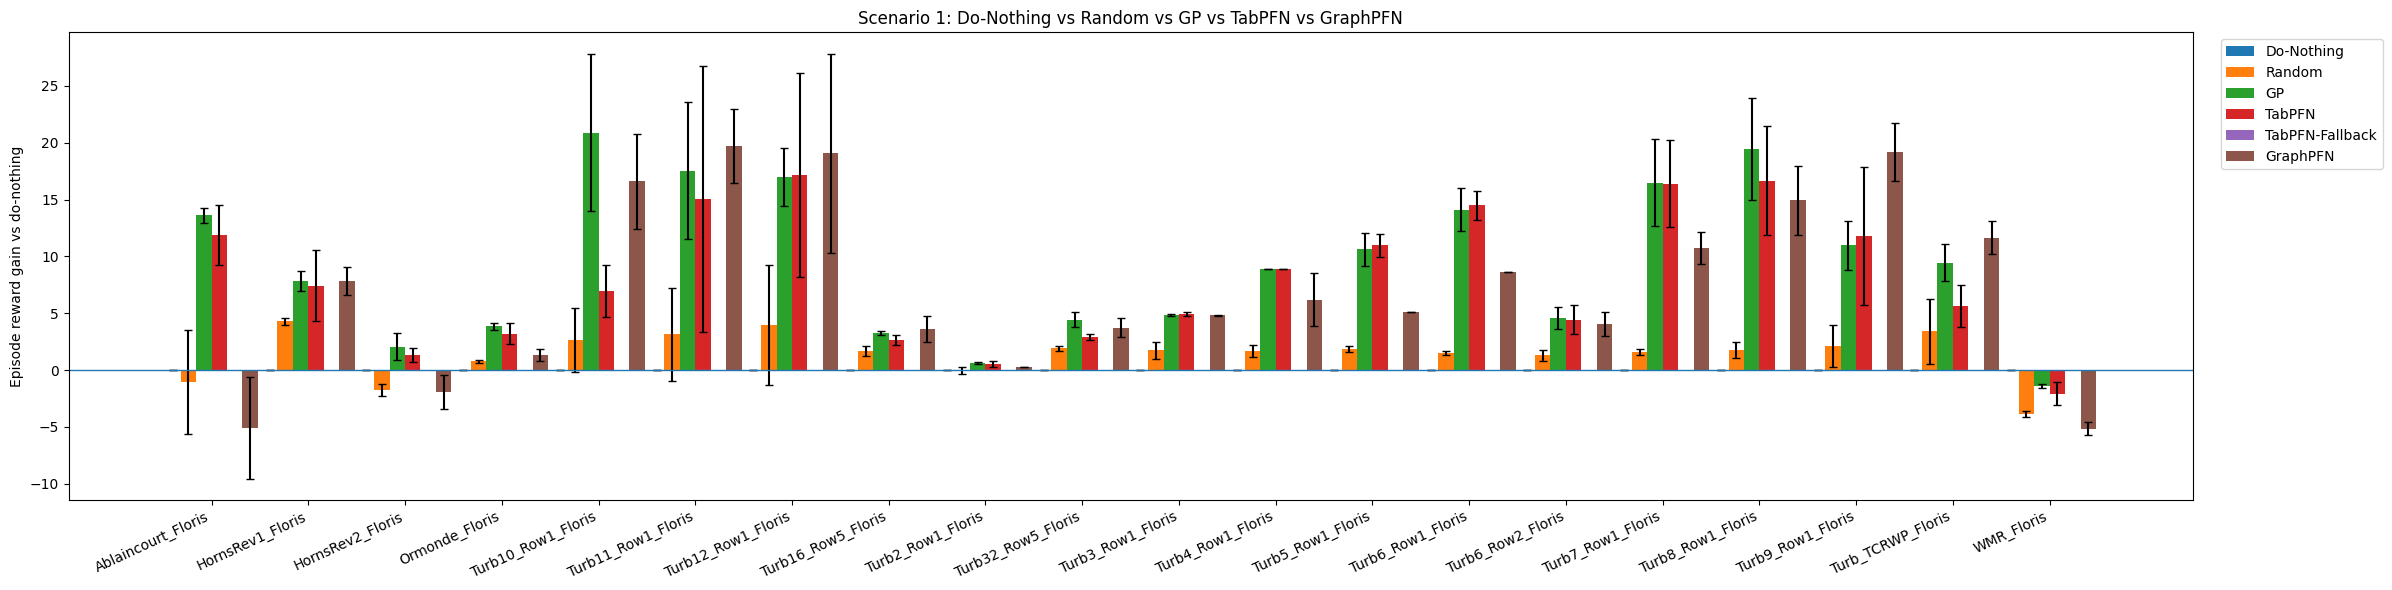

In [17]:
method_order = ["Do-Nothing", "Random", "GP", "TabPFN", "TabPFN-Fallback", "GraphPFN"]
layout_order = list(summary_df["layout"].drop_duplicates())

fig, ax = plt.subplots(figsize=(max(10, 1.2 * len(layout_order)), 6))
width = 0.16
x = np.arange(len(layout_order))

for i, method in enumerate(method_order):
    sub = summary_df[summary_df["method"] == method].set_index("layout").reindex(layout_order)
    ax.bar(
        x + (i - (len(method_order) - 1) / 2) * width,
        sub["mean_gain"].values,
        width=width,
        yerr=sub["std_gain"].values,
        capsize=3,
        label=method,
    )

ax.axhline(0.0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(layout_order, rotation=25, ha="right")
ax.set_ylabel("Episode reward gain vs do-nothing")
ax.set_title("Scenario 1: Do-Nothing vs Random vs GP vs TabPFN vs GraphPFN")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

## WFCRL Scenario 2 FLORIS comparison
These cells train GP, TabPFN, and GraphPFN on randomized Scenario 2 FLORIS contexts and evaluate the selected yaw vectors under the fixed test condition of wind speed 8 m/s and wind direction 270 degrees.


In [18]:
SCENARIO2_TEST_OPTIONS = SCENARIO1_OPTIONS.copy()
SCENARIO2_SEEDS = SEEDS


def scenario2_options_sampler(rng, env=None):
    return sample_scenario2_options(rng, env=env)


preview_rng = np.random.default_rng(2026)
scenario2_context_preview = pd.DataFrame(
    [scenario2_options_sampler(preview_rng) for _ in range(8)]
)
display(scenario2_context_preview)
print("Scenario 2 train context: random WFCRL wind speed/direction")
print("Scenario 2 test context:", SCENARIO2_TEST_OPTIONS)


,wind_speed,wind_direction
0,6.304804,274.811426
1,7.196647,297.915434
2,7.977542,264.159050
3,8.254585,276.076707
4,7.908082,265.481823
5,8.541649,280.294104
6,8.323050,268.290469
7,6.397183,257.719632


Scenario 2 train context: random WFCRL wind speed/direction
Scenario 2 test context: {'wind_speed': 8.0, 'wind_direction': 270.0}


In [19]:
scenario2_preflight_rows = [
    preflight_one_layout(
        name,
        seed=0,
        graph_pfn_model=model,
        scenario_name="Scenario 2",
        options_sampler=scenario2_options_sampler,
        eval_options=SCENARIO2_TEST_OPTIONS,
    )
    for name in (WORKING_LAYOUTS if len(WORKING_LAYOUTS) else LAYOUTS)
]
scenario2_preflight_df = pd.DataFrame(scenario2_preflight_rows)
display(scenario2_preflight_df[[c for c in ["scenario", "layout", "ok", "error"] if c in scenario2_preflight_df.columns]])

SCENARIO2_WORKING_LAYOUTS = (
    scenario2_preflight_df.loc[scenario2_preflight_df["ok"] == True, "layout"].tolist()
    if len(scenario2_preflight_df)
    else []
)
print("Scenario 2 working layouts:", SCENARIO2_WORKING_LAYOUTS)


Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:00<00:00]
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processin

,scenario,layout,ok,error
0,Scenario 2,Ablaincourt_Floris,True,
1,Scenario 2,HornsRev1_Floris,True,
2,Scenario 2,HornsRev2_Floris,True,
3,Scenario 2,Ormonde_Floris,True,
4,Scenario 2,Turb10_Row1_Floris,True,
5,Scenario 2,Turb11_Row1_Floris,True,
6,Scenario 2,Turb12_Row1_Floris,True,
7,Scenario 2,Turb16_Row5_Floris,True,
8,Scenario 2,Turb2_Row1_Floris,True,
9,Scenario 2,Turb32_Row5_Floris,True,


Scenario 2 working layouts: ['Ablaincourt_Floris', 'HornsRev1_Floris', 'HornsRev2_Floris', 'Ormonde_Floris', 'Turb10_Row1_Floris', 'Turb11_Row1_Floris', 'Turb12_Row1_Floris', 'Turb16_Row5_Floris', 'Turb2_Row1_Floris', 'Turb32_Row5_Floris', 'Turb3_Row1_Floris', 'Turb4_Row1_Floris', 'Turb5_Row1_Floris', 'Turb6_Row1_Floris', 'Turb6_Row2_Floris', 'Turb7_Row1_Floris', 'Turb8_Row1_Floris', 'Turb9_Row1_Floris', 'Turb_TCRWP_Floris', 'WMR_Floris']


In [20]:
scenario2_runs = []
scenario2_error_rows = []
SCENARIO2_RUN_LAYOUTS = SCENARIO2_WORKING_LAYOUTS if len(SCENARIO2_WORKING_LAYOUTS) else (WORKING_LAYOUTS if len(WORKING_LAYOUTS) else LAYOUTS)
print("Evaluating Scenario 2 layouts:", SCENARIO2_RUN_LAYOUTS)

for env_name in SCENARIO2_RUN_LAYOUTS:
    print(f"\nRunning Scenario 2 {env_name}")
    for seed in SCENARIO2_SEEDS:
        try:
            df_run = run_one_layout_seed(
                env_name,
                seed,
                model,
                scenario_name="Scenario 2",
                options_sampler=scenario2_options_sampler,
                eval_options=SCENARIO2_TEST_OPTIONS,
            )
            scenario2_runs.append(df_run)
            print(df_run[["scenario", "layout", "seed", "method", "reward"]])
        except Exception as e:
            scenario2_error_rows.append({
                "scenario": "Scenario 2",
                "layout": env_name,
                "seed": seed,
                "error_type": type(e).__name__,
                "error": str(e),
                "traceback": traceback.format_exc(),
            })
            print(f"FAILED Scenario 2 {env_name} seed={seed}: {type(e).__name__}: {e}")

scenario2_errors_df = pd.DataFrame(scenario2_error_rows)
if len(scenario2_errors_df):
    display(scenario2_errors_df[["scenario", "layout", "seed", "error_type", "error"]])

if not scenario2_runs:
    raise RuntimeError(
        "No Scenario 2 results were collected. Check scenario2_preflight_df and "
        "scenario2_errors_df for the first exception."
    )

scenario2_results_df = pd.concat(scenario2_runs, ignore_index=True)
display(scenario2_results_df.head())

results_dir = Path("CSCI_5980_notebooks/results") if Path("CSCI_5980_notebooks").exists() else Path("results")
results_dir.mkdir(parents=True, exist_ok=True)
scenario2_results_path = results_dir / "scenario2_floris_graph_tab_pfn_results.csv"
scenario2_results_df.to_csv(scenario2_results_path, index=False)
print("Saved Scenario 2 results to", scenario2_results_path)


Evaluating Scenario 2 layouts: ['Ablaincourt_Floris', 'HornsRev1_Floris', 'HornsRev2_Floris', 'Ormonde_Floris', 'Turb10_Row1_Floris', 'Turb11_Row1_Floris', 'Turb12_Row1_Floris', 'Turb16_Row5_Floris', 'Turb2_Row1_Floris', 'Turb32_Row5_Floris', 'Turb3_Row1_Floris', 'Turb4_Row1_Floris', 'Turb5_Row1_Floris', 'Turb6_Row1_Floris', 'Turb6_Row2_Floris', 'Turb7_Row1_Floris', 'Turb8_Row1_Floris', 'Turb9_Row1_Floris', 'Turb_TCRWP_Floris', 'WMR_Floris']

Running Scenario 2 Ablaincourt_Floris
[run_one_layout_seed] Scenario 2 Ablaincourt_Floris seed=0 X_tab=(32, 24) y=(32,) graphs=32 test_ws=8.000 test_wd=270.000
  train context ws range= (4.60479736328125, 9.536691665649414) wd range= (240.258544921875, 331.32073974609375)


Processing: 100%|██████████| [00:00<00:00]


     scenario              layout  seed      method      reward
0  Scenario 2  Ablaincourt_Floris     0  Do-Nothing  351.166729
1  Scenario 2  Ablaincourt_Floris     0      Random  348.796185
2  Scenario 2  Ablaincourt_Floris     0          GP  359.443024
3  Scenario 2  Ablaincourt_Floris     0      TabPFN  365.096437
4  Scenario 2  Ablaincourt_Floris     0    GraphPFN  350.256168
[run_one_layout_seed] Scenario 2 Ablaincourt_Floris seed=1 X_tab=(32, 24) y=(32,) graphs=32 test_ws=8.000 test_wd=270.000
  train context ws range= (4.311367034912109, 8.973167419433594) wd range= (215.7742919921875, 332.0008544921875)


Processing: 100%|██████████| [00:00<00:00]


     scenario              layout  seed      method      reward
0  Scenario 2  Ablaincourt_Floris     1  Do-Nothing  351.166729
1  Scenario 2  Ablaincourt_Floris     1      Random  355.206798
2  Scenario 2  Ablaincourt_Floris     1          GP  353.394136
3  Scenario 2  Ablaincourt_Floris     1      TabPFN  362.769117
4  Scenario 2  Ablaincourt_Floris     1    GraphPFN  346.681357
[run_one_layout_seed] Scenario 2 Ablaincourt_Floris seed=2 X_tab=(32, 24) y=(32,) graphs=32 test_ws=8.000 test_wd=270.000
  train context ws range= (3.463167905807495, 9.33950424194336) wd range= (230.60751342773438, 311.1340637207031)


...

     scenario      layout  seed      method      reward
0  Scenario 2  WMR_Floris     1  Do-Nothing  475.011106
1  Scenario 2  WMR_Floris     1      Random  471.035333
2  Scenario 2  WMR_Floris     1          GP  471.035333
3  Scenario 2  WMR_Floris     1      TabPFN  471.027949
4  Scenario 2  WMR_Floris     1    GraphPFN  469.416504
[run_one_layout_seed] Scenario 2 WMR_Floris seed=2 X_tab=(32, 108) y=(32,) graphs=32 test_ws=8.000 test_wd=270.000
  train context ws range= (5.957923889160156, 9.865653991699219) wd range= (233.5397186279297, 323.7864990234375)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
Processing: 100%|██████████| [00:00<00:00]


     scenario      layout  seed      method      reward
0  Scenario 2  WMR_Floris     2  Do-Nothing  475.011106
1  Scenario 2  WMR_Floris     2      Random  471.471093
2  Scenario 2  WMR_Floris     2          GP  471.471093
3  Scenario 2  WMR_Floris     2      TabPFN  472.340096
4  Scenario 2  WMR_Floris     2    GraphPFN  469.621254


,scenario,layout,seed,method,reward,power,predicted_reward,test_wind_speed,test_wind_direction,train_wind_speed_min,train_wind_speed_max,train_wind_direction_min,train_wind_direction_max,n_turbines
0,Scenario 2,Ablaincourt_Floris,0,Do-Nothing,351.166729,1271.612952,NaN,8.0,270.0,4.604797,9.536692,240.258545,331.32074,7
1,Scenario 2,Ablaincourt_Floris,0,Random,348.796185,1262.806496,NaN,8.0,270.0,4.604797,9.536692,240.258545,331.32074,7
2,Scenario 2,Ablaincourt_Floris,0,GP,359.443024,1300.949741,456.996649,8.0,270.0,4.604797,9.536692,240.258545,331.32074,7
3,Scenario 2,Ablaincourt_Floris,0,TabPFN,365.096437,1321.037134,356.440613,8.0,270.0,4.604797,9.536692,240.258545,331.32074,7
4,Scenario 2,Ablaincourt_Floris,0,GraphPFN,350.256168,1268.178380,-0.015325,8.0,270.0,4.604797,9.536692,240.258545,331.32074,7


Saved Scenario 2 results to results/scenario2_floris_graph_tab_pfn_results.csv


In [21]:
scenario2_methods_order = ["Do-Nothing", "Random", "GP", "TabPFN", "TabPFN-Fallback", "GraphPFN"]

scenario2_baseline = (
    scenario2_results_df[scenario2_results_df["method"] == "Do-Nothing"]
    [["layout", "seed", "reward"]]
    .rename(columns={"reward": "baseline_reward"})
)

scenario2_plot_df = scenario2_results_df.merge(scenario2_baseline, on=["layout", "seed"], how="left")
scenario2_plot_df["reward_gain_vs_do_nothing"] = scenario2_plot_df["reward"] - scenario2_plot_df["baseline_reward"]

scenario2_summary_df = (
    scenario2_plot_df.groupby(["layout", "method"], as_index=False)
    .agg(
        mean_gain=("reward_gain_vs_do_nothing", "mean"),
        std_gain=("reward_gain_vs_do_nothing", "std"),
        mean_reward=("reward", "mean"),
        std_reward=("reward", "std"),
        mean_train_wind_speed_min=("train_wind_speed_min", "mean"),
        mean_train_wind_speed_max=("train_wind_speed_max", "mean"),
        mean_train_wind_direction_min=("train_wind_direction_min", "mean"),
        mean_train_wind_direction_max=("train_wind_direction_max", "mean"),
    )
    .fillna(0.0)
)

scenario2_summary_df["method"] = pd.Categorical(
    scenario2_summary_df["method"],
    categories=scenario2_methods_order,
    ordered=True,
)
scenario2_summary_df = scenario2_summary_df.sort_values(["layout", "method"]).reset_index(drop=True)

scenario2_summary_path = results_dir / "scenario2_floris_graph_tab_pfn_summary.csv"
scenario2_summary_df.to_csv(scenario2_summary_path, index=False)
print("Saved Scenario 2 summary to", scenario2_summary_path)
scenario2_summary_df


Saved Scenario 2 summary to results/scenario2_floris_graph_tab_pfn_summary.csv


,layout,method,mean_gain,std_gain,mean_reward,std_reward,mean_train_wind_speed_min,mean_train_wind_speed_max,mean_train_wind_direction_min,mean_train_wind_direction_max
0,Ablaincourt_Floris,Do-Nothing,0.000000,0.000000,351.166729,0.000000,4.126444,9.283121,228.880117,324.818553
1,Ablaincourt_Floris,Random,-1.041178,4.564149,350.125550,4.564149,4.126444,9.283121,228.880117,324.818553
2,Ablaincourt_Floris,GP,5.453941,3.044632,356.620670,3.044632,4.126444,9.283121,228.880117,324.818553
3,Ablaincourt_Floris,TabPFN,12.496336,1.253929,363.663065,1.253929,4.126444,9.283121,228.880117,324.818553
4,Ablaincourt_Floris,GraphPFN,-5.068423,4.477948,346.098306,4.477948,4.126444,9.283121,228.880117,324.818553
...,...,...,...,...,...,...,...,...,...,...
95,WMR_Floris,Do-Nothing,0.000000,0.000000,475.011106,0.000000,4.906886,9.685880,233.295339,313.617299
96,WMR_Floris,Random,-3.847862,0.267871,471.163245,0.267871,4.906886,9.685880,233.295339,313.617299
97,WMR_Floris,GP,-3.847862,0.267871,471.163245,0.267871,4.906886,9.685880,233.295339,313.617299
98,WMR_Floris,TabPFN,-3.095061,0.769375,471.916046,0.769375,4.906886,9.685880,233.295339,313.617299


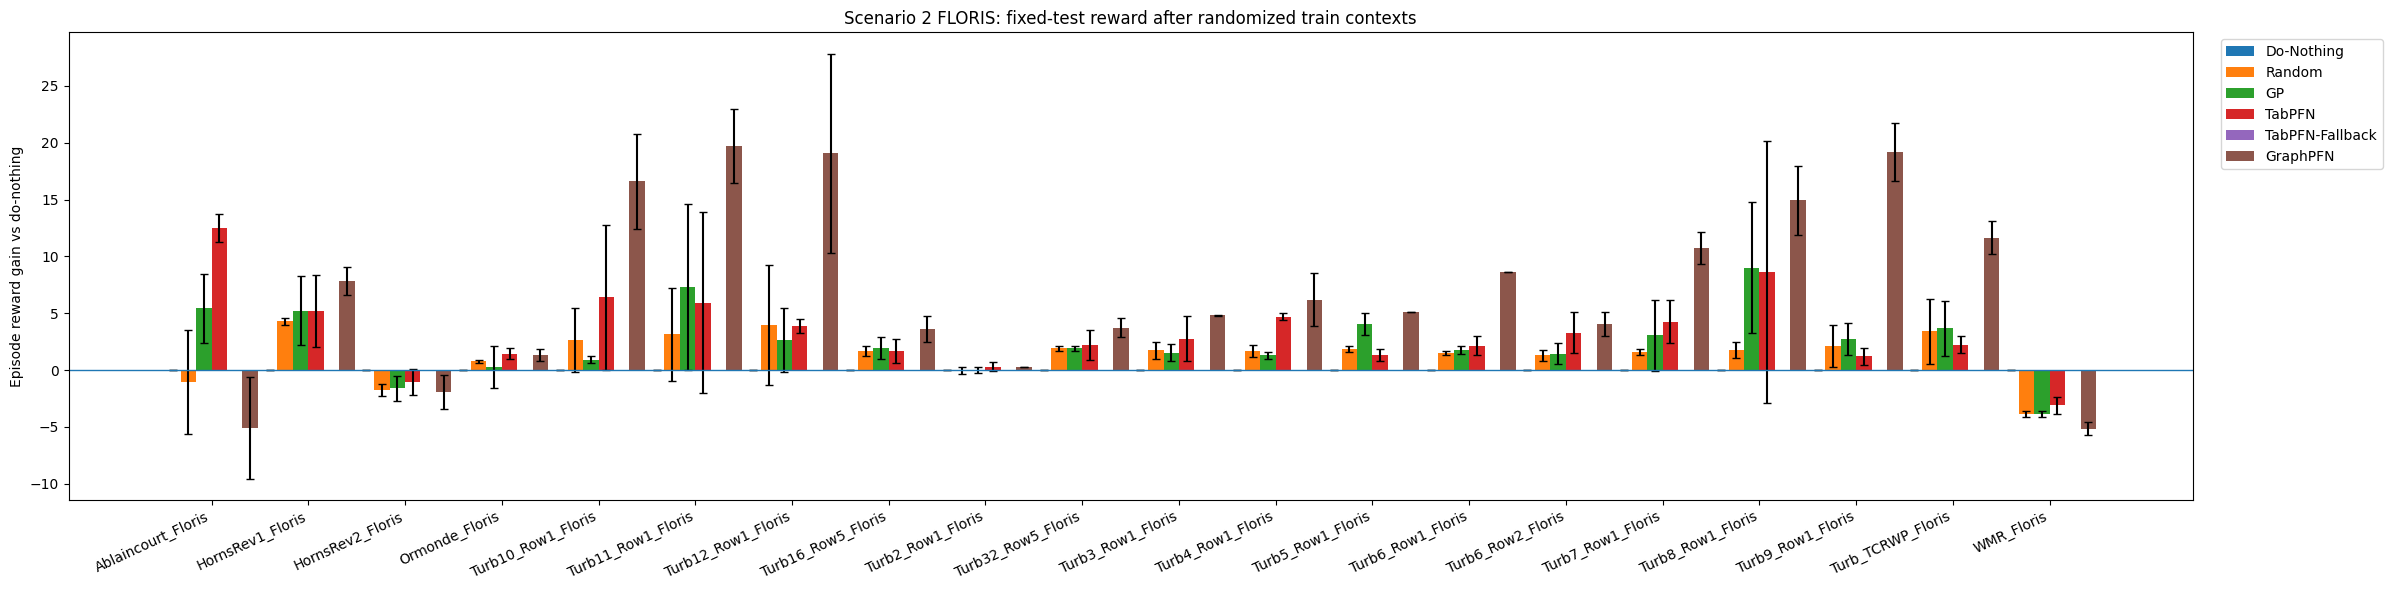

In [22]:
scenario2_method_order = ["Do-Nothing", "Random", "GP", "TabPFN", "TabPFN-Fallback", "GraphPFN"]
scenario2_layout_order = list(scenario2_summary_df["layout"].drop_duplicates())

fig, ax = plt.subplots(figsize=(max(10, 1.2 * len(scenario2_layout_order)), 6))
width = 0.16
x = np.arange(len(scenario2_layout_order))

for i, method in enumerate(scenario2_method_order):
    sub = scenario2_summary_df[scenario2_summary_df["method"] == method].set_index("layout").reindex(scenario2_layout_order)
    ax.bar(
        x + (i - (len(scenario2_method_order) - 1) / 2) * width,
        sub["mean_gain"].values,
        width=width,
        yerr=sub["std_gain"].values,
        capsize=3,
        label=method,
    )

ax.axhline(0.0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(scenario2_layout_order, rotation=25, ha="right")
ax.set_ylabel("Episode reward gain vs do-nothing")
ax.set_title("Scenario 2 FLORIS: fixed-test reward after randomized train contexts")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()


In [23]:
graphpfn_rank_diagnostic(
    "Turb3_Row1_Floris",
    seed=0,
    graph_pfn_model=model,
    n_candidates=128,
    scenario_name="Scenario 2",
    options_sampler=scenario2_options_sampler,
    eval_options=SCENARIO2_TEST_OPTIONS,
)


Processing: 100%|██████████| [00:00<00:00]


,scenario,method,spearman_rank_corr
0,Scenario 2,GP,0.014339
1,Scenario 2,TabPFN,0.281245
2,Scenario 2,GraphPFN,0.243679
